<a href="https://colab.research.google.com/github/Ameeghai/Quantum-RNG-Hybrid/blob/BSP-(NOISE-ANALYSIS)/noise_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
!pip install qiskit

In [22]:
!pip install qiskit_aer

In [23]:
!pip install pylatexenc


  Using cached pylatexenc-2.10.tar.gz (162 kB)
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=c8d0aee8528c9af8e872401a099db2a3316c8aea24c95918ad581921e3a04a03
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


Example random number generated: 2450170131
Shannon entropy: 12.2877 bits (max = 32)
Min-entropy: 12.2877 bits


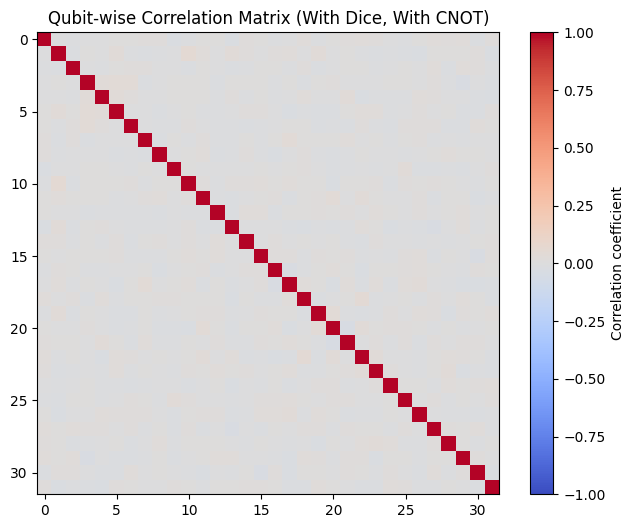

Average off-diagonal correlation = 0.0114

First 20 measurement sequences (shots):
[[0 1 1 1 1 1 0 1 1 1 0 1 0 1 0 0 0 1 1 0 0 0 1 1 0 1 1 1 0 0 1 0]
 [0 0 1 0 0 1 1 1 1 0 0 0 1 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 1 1 0 1]
 [1 0 0 1 1 1 1 0 0 0 0 1 1 1 0 1 1 0 0 0 0 1 1 0 1 1 1 1 0 0 1 0]
 [0 1 1 1 1 1 1 1 1 0 1 0 1 1 0 0 1 0 1 0 0 1 0 0 0 1 1 1 1 0 1 1]
 [1 1 1 1 1 0 0 1 0 0 1 1 0 0 1 0 0 0 0 1 1 1 1 0 1 1 0 1 1 1 0 0]
 [0 0 0 1 0 1 1 1 1 0 0 0 0 1 1 0 1 0 1 0 0 1 1 0 1 1 0 0 0 0 0 1]
 [0 1 1 0 0 1 1 1 1 1 0 1 1 1 1 0 0 1 1 0 0 1 0 0 0 1 0 1 1 1 0 1]
 [1 0 0 1 0 1 0 0 1 1 0 0 0 1 1 0 0 0 0 1 0 1 1 1 0 1 0 0 0 1 0 0]
 [1 0 0 0 0 1 1 1 1 0 0 1 0 1 1 1 0 1 0 0 1 0 1 1 1 0 1 1 1 0 1 1]
 [0 1 1 0 1 1 1 0 0 1 0 1 0 1 1 1 1 1 0 1 1 1 0 1 0 0 0 0 1 1 0 1]
 [1 1 0 0 1 0 1 1 1 0 1 0 0 1 1 0 0 0 0 1 1 1 0 0 0 0 0 0 1 1 0 1]
 [0 1 1 1 0 0 1 1 0 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 0 0 1]
 [0 1 1 0 0 1 0 0 1 0 0 0 0 0 0 1 1 1 1 0 0 1 0 0 1 0 1 0 1 1 1 0]
 [0 0 1 1 1 0 1 0 1 0 1 1 1 0 1 0 0 0 0 1 0 1 

In [24]:
# Hybrid QRNG: 32-bit, With Dice, With CNOT (5000 shots)
import numpy as np
from math import log2
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt
import random

# ----------------------------
# Step 1: Shot-Noise
def generate_shot_noise_bits(length=32):
    return np.random.choice([0, 1], size=length, p=[0.5, 0.5])

shot_noise_bits = generate_shot_noise_bits(32)

# ----------------------------
# Step 2: Quantum Circuit
qc = QuantumCircuit(32, 32)
for i, bit in enumerate(shot_noise_bits):
    if bit == 1:
        qc.x(i)

# ----------------------------
# Step 3: Hadamard
for q in range(32):
    qc.h(q)

# ----------------------------
# Step 4: Dice for Random CNOT Pairs
def dice_pairs(num_qubits=32):
    available = list(range(num_qubits))
    pairs = []
    while len(available) >= 2:
        d1, d2 = random.sample(available, 2)
        pairs.append((d1, d2))
        available.remove(d1)
        available.remove(d2)
    return pairs

pairs = dice_pairs(32)
for ctrl, tgt in pairs:
    qc.cx(ctrl, tgt)

# Dice measurement order
def dice_measurement_order(num_qubits=32):
    available = list(range(num_qubits))
    order = []
    while available:
        choice = random.choice(available)
        order.append(choice)
        available.remove(choice)
    return order

measurement_order = dice_measurement_order(32)
for idx, q in enumerate(measurement_order):
    qc.measure(q, idx)

# ----------------------------
# Step 5: Run Simulation
simulator = AerSimulator()
result = simulator.run(qc, shots=5000).result()
counts = result.get_counts()

# ----------------------------
# Step 6: Random Number, Entropy, Correlation
outcomes = list(counts.keys())
probabilities = np.array(list(counts.values())) / sum(list(counts.values()))
measured_bits = np.random.choice(outcomes, p=probabilities)
random_number = int(measured_bits, 2)
print(f"Example random number generated: {random_number}")

entropy = -np.sum([p*log2(p) for p in probabilities if p>0])
min_entropy = -log2(np.max(probabilities))
print(f"Shannon entropy: {entropy:.4f} bits (max = 32)")
print(f"Min-entropy: {min_entropy:.4f} bits")

bit_matrix = np.array([list(map(int, o)) for o in np.repeat(outcomes, list(counts.values()), axis=0)])
correlation_matrix = np.corrcoef(bit_matrix.T)
plt.figure(figsize=(8,6))
plt.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation coefficient')
plt.title("Qubit-wise Correlation Matrix (With Dice, With CNOT)")
plt.show()

num_qubits = correlation_matrix.shape[0]
avg_off_diag_corr = (np.sum(np.abs(correlation_matrix)) - num_qubits) / (num_qubits*(num_qubits-1))
print(f"Average off-diagonal correlation = {avg_off_diag_corr:.4f}")

print("\nFirst 20 measurement sequences (shots):")
print(bit_matrix[:20])


In [25]:
import numpy as np
from math import log2
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt
import random

In [26]:
def compute_bitwise_entropy(counts):
    outcomes = list(counts.keys())
    counts_list = list(counts.values())

    bit_matrix = np.array([
        list(map(int, o))
        for o in np.repeat(outcomes, counts_list, axis=0)
    ])

    entropies = []

    for i in range(32):
        col = bit_matrix[:, i]
        p1 = np.mean(col)
        p0 = 1 - p1

        if p0 > 0 and p1 > 0:
            h = -(p0*log2(p0) + p1*log2(p1))
        else:
            h = 0

        entropies.append(h)

    avg_entropy = np.mean(entropies)

    return avg_entropy, avg_entropy*32

In [27]:
# Layer 1

num_samples = 1000
num_bits = 32

data = np.random.choice([0,1], size=(num_samples, num_bits), p=[0.5,0.5])

entropies = []
for i in range(num_bits):
    col = data[:, i]
    p1 = np.mean(col)
    p0 = 1 - p1
    h = -(p0*log2(p0) + p1*log2(p1))
    entropies.append(h)

print("Layer 1 Avg entropy:", np.mean(entropies))

Layer 1 Avg entropy: 0.9989579539774534


In [28]:
# Layer 2

bits = np.random.choice([0,1], size=32, p=[0.5,0.5])

p_init = 0.5
flip_mask = np.random.rand(32) < p_init
bits = np.logical_xor(bits, flip_mask).astype(int)

p1 = np.mean(bits)
p0 = 1 - p1

entropy = -(p0*log2(p0) + p1*log2(p1))

print("Layer 2 entropy:", entropy)

Layer 2 entropy: 0.9971803988942642


In [29]:
# Layer 3

qc = QuantumCircuit(32, 32)

for i, bit in enumerate(bits):
    if bit == 1:
        qc.x(i)

for i in range(32):
    qc.h(i)

available = list(range(32))
while len(available) >= 2:
    a, b = random.sample(available, 2)
    qc.cx(a, b)
    available.remove(a)
    available.remove(b)

for i in range(32):
    qc.measure(i, i)

sim = AerSimulator()
result = sim.run(qc, shots=5000).result()
counts = result.get_counts()

avg_h, total_h = compute_bitwise_entropy(counts)

print("Layer 3 Avg entropy:", avg_h)
print("Layer 3 Total entropy:", total_h)

Layer 3 Avg entropy: 0.9998758318613559
Layer 3 Total entropy: 31.996026619563388


In [30]:
# Layer 4

def apply_measurement_noise(counts, p_meas=0.02):
    new_counts = {}
    for bitstring, count in counts.items():
        for _ in range(count):
            bits = list(bitstring)
            for i in range(len(bits)):
                if np.random.rand() < p_meas:
                    bits[i] = '1' if bits[i]=='0' else '0'
            new_str = ''.join(bits)
            new_counts[new_str] = new_counts.get(new_str, 0) + 1
    return new_counts

counts_noisy = apply_measurement_noise(counts, p_meas=0.02)

avg_h, total_h = compute_bitwise_entropy(counts_noisy)

print("Layer 4 Avg entropy:", avg_h)
print("Layer 4 Total entropy:", total_h)

Layer 4 Avg entropy: 0.9998638998494425
Layer 4 Total entropy: 31.99564479518216


Layer 5 Avg correlation: 0.011015079093894098


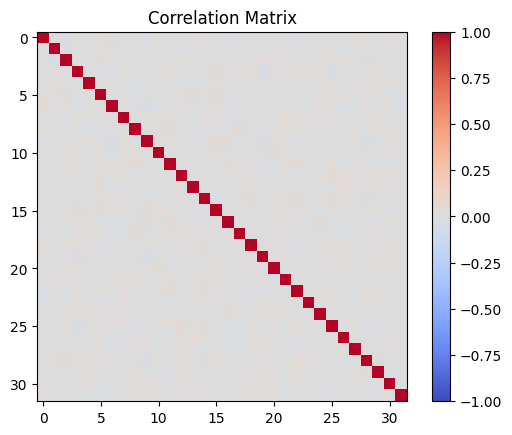

In [31]:
# Layer 5

outcomes = list(counts_noisy.keys())
counts_list = list(counts_noisy.values())

bit_matrix = np.array([
    list(map(int, o))
    for o in np.repeat(outcomes, counts_list, axis=0)
])

corr = np.corrcoef(bit_matrix.T)

avg_corr = (np.sum(np.abs(corr)) - 32) / (32*31)

print("Layer 5 Avg correlation:", avg_corr)

plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.title("Correlation Matrix")
plt.show()

In [32]:
# FULL PIPELINE

# Layer 1
bits = np.random.choice([0,1], size=32, p=[0.5,0.5])

# Layer 2
p_init = 0.02
flip_mask = np.random.rand(32) < p_init
bits = np.logical_xor(bits, flip_mask).astype(int)

# Layer 3
qc = QuantumCircuit(32, 32)

for i, bit in enumerate(bits):
    if bit == 1:
        qc.x(i)

for i in range(32):
    qc.h(i)

available = list(range(32))
while len(available) >= 2:
    a, b = random.sample(available, 2)
    qc.cx(a, b)
    available.remove(a)
    available.remove(b)

for i in range(32):
    qc.measure(i, i)

sim = AerSimulator()
result = sim.run(qc, shots=5000).result()
counts = result.get_counts()

# ----------------------------
# Layer 4: Measurement Noise
counts = apply_measurement_noise(counts, p_meas=0.02)

# ----------------------------
# Layer 5: ANALYSIS

# ---- Bit-wise entropy (already done)
avg_h, total_h = compute_bitwise_entropy(counts)

# ---- Shannon entropy (full 32-bit strings)
outcomes = list(counts.keys())
probs = np.array(list(counts.values())) / sum(counts.values())

shannon_entropy = -np.sum([p * log2(p) for p in probs if p > 0])

# ---- Build bit matrix for correlation
bit_matrix = np.array([
    list(map(int, o))
    for o in np.repeat(outcomes, list(counts.values()), axis=0)
])

# ---- Correlation matrix
corr_matrix = np.corrcoef(bit_matrix.T)

num_qubits = corr_matrix.shape[0]

# Average off-diagonal correlation
avg_off_diag_corr = (
    np.sum(np.abs(corr_matrix)) - num_qubits
) / (num_qubits * (num_qubits - 1))

# ----------------------------
# PRINT RESULTS

print("Final Avg entropy per bit:", avg_h)
print("Final Total entropy (~32 bits):", total_h)

print("Shannon entropy (full strings):", shannon_entropy)

print("Average off-diagonal correlation:", avg_off_diag_corr)

Final Avg entropy per bit: 0.9998192277194099
Final Total entropy (~32 bits): 31.994215287021117
Shannon entropy (full strings): 12.287712379549447
Average off-diagonal correlation: 0.010754367898040951


In [33]:
# ----------------------------
# FUNCTION TO RUN PIPELINE

def run_pipeline(p_init=0, p_meas=0):

    # Layer 1
    bits = np.random.choice([0,1], size=32, p=[0.5,0.5])

    # Layer 2
    flip_mask = np.random.rand(32) < p_init
    bits = np.logical_xor(bits, flip_mask).astype(int)

    # Layer 3
    qc = QuantumCircuit(32, 32)

    for i, bit in enumerate(bits):
        if bit == 1:
            qc.x(i)

    for i in range(32):
        qc.h(i)

    available = list(range(32))
    while len(available) >= 2:
        a, b = random.sample(available, 2)
        qc.cx(a, b)
        available.remove(a)
        available.remove(b)

    for i in range(32):
        qc.measure(i, i)

    sim = AerSimulator()
    result = sim.run(qc, shots=5000).result()
    counts = result.get_counts()

    # Measurement noise
    if p_meas > 0:
        counts = apply_measurement_noise(counts, p_meas)

    # ----------------------------
    # ANALYSIS

    outcomes = list(counts.keys())
    probs = np.array(list(counts.values())) / sum(counts.values())

    # Shannon entropy
    shannon = -np.sum([p*log2(p) for p in probs if p > 0])

    # Min entropy
    min_entropy = -log2(np.max(probs))

    # Bit-wise entropy
    avg_h, total_h = compute_bitwise_entropy(counts)

    # Correlation
    bit_matrix = np.array([
        list(map(int, o))
        for o in np.repeat(outcomes, list(counts.values()), axis=0)
    ])

    corr = np.corrcoef(bit_matrix.T)
    num_q = corr.shape[0]

    avg_corr = (np.sum(np.abs(corr)) - num_q) / (num_q*(num_q-1))

    return {
        "avg_bit_entropy": avg_h,
        "total_entropy": total_h,
        "shannon_entropy": shannon,
        "min_entropy": min_entropy,
        "correlation": avg_corr
    }

# ----------------------------
# RUN BOTH CASES

no_noise = run_pipeline(p_init=0, p_meas=0)
with_noise = run_pipeline(p_init=0.02, p_meas=0.02)

# ----------------------------
# PRINT COMPARISON

print("\n--- WITHOUT NOISE ---")
for k, v in no_noise.items():
    print(f"{k}: {v}")

print("\n--- WITH NOISE ---")
for k, v in with_noise.items():
    print(f"{k}: {v}")


--- WITHOUT NOISE ---
avg_bit_entropy: 0.9998190164033454
total_entropy: 31.99420852490705
shannon_entropy: 12.287712379549447
min_entropy: 12.287712379549449
correlation: 0.011499127140165634

--- WITH NOISE ---
avg_bit_entropy: 0.9998302877009754
total_entropy: 31.994569206431212
shannon_entropy: 12.287712379549447
min_entropy: 12.287712379549449
correlation: 0.01080016238958244


In [34]:
# ============================================================
# BINARY FILE SAVING UTILITIES
# Saves QRNG output bitstreams as raw binary (.bin) files
# ============================================================
import os
import struct
import numpy as np

def counts_to_bit_matrix(counts):
    """Convert Qiskit counts dict to a full bit matrix (shots x 32)."""
    outcomes   = list(counts.keys())
    counts_arr = list(counts.values())
    bit_matrix = np.array([
        list(map(int, o))
        for o in np.repeat(outcomes, counts_arr, axis=0)
    ], dtype=np.uint8)          # uint8: each element is 0 or 1
    return bit_matrix


def save_bits_as_binary(bit_matrix, filepath):
    """
    Pack a (shots x 32) bit matrix into a raw binary file.

    File layout
    -----------
    Header  : 4 bytes  – magic number  0x51524E47  ('QRNG')
              4 bytes  – num_shots     (uint32, little-endian)
              4 bytes  – num_bits      (uint32, little-endian)  = 32
    Payload : each row of 32 bits is packed into 4 bytes (uint32).
              Total payload = num_shots * 4 bytes.

    Returns
    -------
    filepath : str   (same value passed in)
    """
    os.makedirs(os.path.dirname(filepath) if os.path.dirname(filepath) else '.', exist_ok=True)

    num_shots, num_bits = bit_matrix.shape

    with open(filepath, 'wb') as f:
        # --- Header ---
        f.write(b'QRNG')                                      # 4-byte magic
        f.write(struct.pack('<I', num_shots))                  # num_shots
        f.write(struct.pack('<I', num_bits))                   # num_bits (32)

        # --- Payload: pack 32 bits per row into one uint32 ---
        for row in bit_matrix:
            number = int(''.join(map(str, row)), 2)            # bits → integer
            f.write(struct.pack('<I', number))                 # 4 bytes LE

    file_size_kb = os.path.getsize(filepath) / 1024
    print(f"  Saved  : {filepath}")
    print(f"  Shots  : {num_shots}")
    print(f"  Bits   : {num_bits} per shot")
    print(f"  Size   : {file_size_kb:.2f} KB")
    return filepath


def load_binary_qrng(filepath):
    """
    Load a binary file saved by save_bits_as_binary().

    Returns
    -------
    bit_matrix : np.ndarray  shape (num_shots, num_bits)  dtype uint8
    """
    with open(filepath, 'rb') as f:
        magic     = f.read(4)
        if magic != b'QRNG':
            raise ValueError(f"Not a QRNG binary file: {filepath}")
        num_shots = struct.unpack('<I', f.read(4))[0]
        num_bits  = struct.unpack('<I', f.read(4))[0]

        rows = []
        for _ in range(num_shots):
            number = struct.unpack('<I', f.read(4))[0]
            bits   = [(number >> (num_bits - 1 - j)) & 1
                      for j in range(num_bits)]
            rows.append(bits)

    return np.array(rows, dtype=np.uint8)


print("Binary save/load utilities ready.")


Binary save/load utilities ready.


In [35]:
# ============================================================
# SAVE BEFORE-NOISE AND AFTER-NOISE OUTPUTS AS BINARY FILES
# ============================================================

print("Running pipeline to capture before/after noise outputs...\n")

# ── Layer 1: Classical seed ──────────────────────────────────────
bits = np.random.choice([0, 1], size=32, p=[0.5, 0.5])

# ── Layer 2: Initialization noise ───────────────────────────────
p_init = 0.02
flip_mask = np.random.rand(32) < p_init
bits = np.logical_xor(bits, flip_mask).astype(int)

# ── Layer 3: Quantum circuit ─────────────────────────────────────
qc = QuantumCircuit(32, 32)
for i, bit in enumerate(bits):
    if bit == 1:
        qc.x(i)
for i in range(32):
    qc.h(i)
available = list(range(32))
while len(available) >= 2:
    a, b = random.sample(available, 2)
    qc.cx(a, b)
    available.remove(a)
    available.remove(b)
for i in range(32):
    qc.measure(i, i)

sim    = AerSimulator()
result = sim.run(qc, shots=5000).result()
counts_before_noise = result.get_counts()   # ← pure quantum output

# ── Layer 4: Measurement noise ───────────────────────────────────
p_meas = 0.02
counts_after_noise = apply_measurement_noise(counts_before_noise, p_meas=p_meas)

# ─────────────────────────────────────────────────────────────────
# BUILD BIT MATRICES
# ─────────────────────────────────────────────────────────────────
bits_before = counts_to_bit_matrix(counts_before_noise)
bits_after  = counts_to_bit_matrix(counts_after_noise)

# ─────────────────────────────────────────────────────────────────
# SAVE AS BINARY FILES
# ─────────────────────────────────────────────────────────────────
print("=" * 50)
print("BEFORE NOISE  (pure quantum circuit output)")
print("=" * 50)
save_bits_as_binary(bits_before, "qrng_output_BEFORE_noise.bin")

print()
print("=" * 50)
print("AFTER NOISE   (post measurement-noise output)")
print("=" * 50)
save_bits_as_binary(bits_after, "qrng_output_AFTER_noise.bin")

print()
print("Both binary files saved successfully.")


Running pipeline to capture before/after noise outputs...

BEFORE NOISE  (pure quantum circuit output)
  Saved  : qrng_output_BEFORE_noise.bin
  Shots  : 5000
  Bits   : 32 per shot
  Size   : 19.54 KB

AFTER NOISE   (post measurement-noise output)
  Saved  : qrng_output_AFTER_noise.bin
  Shots  : 5000
  Bits   : 32 per shot
  Size   : 19.54 KB

Both binary files saved successfully.


In [36]:
# ============================================================
# VERIFY SAVED BINARY FILES  (reload & compare entropy)
# ============================================================
from math import log2

def quick_entropy(bit_matrix):
    """Compute average per-bit Shannon entropy of a bit matrix."""
    entropies = []
    for col_idx in range(bit_matrix.shape[1]):
        col = bit_matrix[:, col_idx]
        p1  = np.mean(col)
        p0  = 1 - p1
        if 0 < p1 < 1:
            entropies.append(-(p0 * log2(p0) + p1 * log2(p1)))
        else:
            entropies.append(0.0)
    return float(np.mean(entropies))


# Reload from disk
loaded_before = load_binary_qrng("qrng_output_BEFORE_noise.bin")
loaded_after  = load_binary_qrng("qrng_output_AFTER_noise.bin")

# Sanity check: shapes must match originals
assert loaded_before.shape == bits_before.shape, "BEFORE shape mismatch!"
assert loaded_after.shape  == bits_after.shape,  "AFTER shape mismatch!"

# Sanity check: content must be identical
assert np.array_equal(loaded_before, bits_before), "BEFORE data mismatch!"
assert np.array_equal(loaded_after,  bits_after),  "AFTER data mismatch!"

print("Verification Results")
print("=" * 50)
print(f"{'File':<40} {'Shape':<18} {'Avg Bit Entropy'}")
print("-" * 78)
print(f"{'qrng_output_BEFORE_noise.bin':<40} "
      f"{str(loaded_before.shape):<18} "
      f"{quick_entropy(loaded_before):.7f}")
print(f"{'qrng_output_AFTER_noise.bin':<40} "
      f"{str(loaded_after.shape):<18} "
      f"{quick_entropy(loaded_after):.7f}")
print("=" * 50)
print("All assertions passed. Binary files are valid.")

# Show first 5 rows of each as a sanity-check preview
print("\nFirst 5 rows — BEFORE noise:")
print(loaded_before[:5])
print("\nFirst 5 rows — AFTER noise:")
print(loaded_after[:5])


Verification Results
File                                     Shape              Avg Bit Entropy
------------------------------------------------------------------------------
qrng_output_BEFORE_noise.bin             (5000, 32)         0.9998327
qrng_output_AFTER_noise.bin              (5000, 32)         0.9998280
All assertions passed. Binary files are valid.

First 5 rows — BEFORE noise:
[[0 0 1 1 1 1 1 1 1 0 1 1 0 0 1 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 1 1 1 0 1 1 1 1 1 1 0 1 0 0 0 1 0 0 0 1 1 0 0 1 1 1 0 0 1 0]
 [0 1 0 1 0 1 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 1 1 0 0 1 1 1 0 0 1 1]
 [1 1 0 0 1 0 1 0 0 1 1 1 0 0 1 0 1 0 1 0 0 1 1 0 0 0 1 1 1 0 1 0]
 [1 1 0 1 1 1 0 1 0 1 0 1 1 0 1 1 0 1 1 1 0 1 1 1 0 1 1 0 0 0 1 1]]

First 5 rows — AFTER noise:
[[0 0 1 1 1 1 1 1 1 0 1 1 0 0 1 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 1 1 1 0 1 1 0 1 1 1 0 1 0 1 0 1 0 0 0 1 1 0 0 1 1 1 0 0 1 0]
 [0 0 0 1 0 1 0 0 0 0 1 1 0 0 1 0 1 1 0 0 0 0 1 0 0 1 1 1 0 0 1 1]
 [1 1 0 0 1 0 1 0 0 1 1 1 0 0 1 0 1 0 1 0

In [37]:
# ----------------------------
# GENERATE ONE RANDOM NUMBER FROM FINAL DISTRIBUTION

# Convert counts → probabilities
outcomes = list(counts.keys())
probs = np.array(list(counts.values())) / sum(counts.values())

# Sample one outcome
selected_bitstring = np.random.choice(outcomes, p=probs)

# Convert binary → decimal
random_number = int(selected_bitstring, 2)

print("\nGenerated 32-bit random bitstring:")
print(selected_bitstring)

print("\nGenerated random number (decimal):")
print(random_number)


Generated 32-bit random bitstring:
10101001111001010101111011110001

Generated random number (decimal):
2850381553


In [38]:
# ============================================================
# SAVE run_pipeline() COMPARISON OUTPUTS AS BINARY FILES
# Captures the full no-noise vs with-noise robustness test
# ============================================================

def run_pipeline_with_save(p_init=0, p_meas=0, save_prefix=None):
    """
    Full QRNG pipeline.  If save_prefix is given, saves:
      <save_prefix>_before_noise.bin  – pure quantum output
      <save_prefix>_after_noise.bin   – post readout-noise output
    Returns the metrics dict (same as original run_pipeline).
    """
    # Layer 1
    bits = np.random.choice([0, 1], size=32, p=[0.5, 0.5])

    # Layer 2: init noise
    flip_mask = np.random.rand(32) < p_init
    bits = np.logical_xor(bits, flip_mask).astype(int)

    # Layer 3: quantum circuit
    qc = QuantumCircuit(32, 32)
    for i, bit in enumerate(bits):
        if bit == 1:
            qc.x(i)
    for i in range(32):
        qc.h(i)
    available = list(range(32))
    while len(available) >= 2:
        a, b = random.sample(available, 2)
        qc.cx(a, b)
        available.remove(a)
        available.remove(b)
    for i in range(32):
        qc.measure(i, i)

    sim    = AerSimulator()
    result = sim.run(qc, shots=5000).result()
    counts_raw = result.get_counts()     # BEFORE readout noise

    # ── Save BEFORE-noise binary ──────────────────────────────────
    if save_prefix:
        bm_before = counts_to_bit_matrix(counts_raw)
        save_bits_as_binary(bm_before, f"{save_prefix}_before_noise.bin")

    # Layer 4: readout noise
    counts = counts_raw
    if p_meas > 0:
        counts = apply_measurement_noise(counts, p_meas)

    # ── Save AFTER-noise binary ───────────────────────────────────
    if save_prefix:
        bm_after = counts_to_bit_matrix(counts)
        save_bits_as_binary(bm_after, f"{save_prefix}_after_noise.bin")

    # Layer 5: analysis
    outcomes = list(counts.keys())
    probs    = np.array(list(counts.values())) / sum(counts.values())
    shannon  = -np.sum([p * log2(p) for p in probs if p > 0])
    min_ent  = -log2(np.max(probs))
    avg_h, total_h = compute_bitwise_entropy(counts)
    bit_matrix = np.array([
        list(map(int, o))
        for o in np.repeat(outcomes, list(counts.values()), axis=0)
    ])
    corr   = np.corrcoef(bit_matrix.T)
    num_q  = corr.shape[0]
    avg_cr = (np.sum(np.abs(corr)) - num_q) / (num_q * (num_q - 1))

    return {
        "avg_bit_entropy": avg_h,
        "total_entropy":   total_h,
        "shannon_entropy": shannon,
        "min_entropy":     min_ent,
        "correlation":     avg_cr
    }


# ── Run WITHOUT noise ─────────────────────────────────────────────
print("Running NO-NOISE pipeline...")
no_noise = run_pipeline_with_save(
    p_init=0, p_meas=0,
    save_prefix="pipeline_no_noise"
)

print()
# ── Run WITH noise ────────────────────────────────────────────────
print("Running WITH-NOISE pipeline...")
with_noise = run_pipeline_with_save(
    p_init=0.02, p_meas=0.02,
    save_prefix="pipeline_with_noise"
)

# ── Print comparison ──────────────────────────────────────────────
print()
print("=" * 50)
print("--- WITHOUT NOISE ---")
for k, v in no_noise.items():
    print(f"  {k}: {v}")

print()
print("--- WITH NOISE ---")
for k, v in with_noise.items():
    print(f"  {k}: {v}")

print()
print("Binary files saved:")
print("  pipeline_no_noise_before_noise.bin   (no-noise run, pure quantum)")
print("  pipeline_no_noise_after_noise.bin    (no-noise run, post readout)")
print("  pipeline_with_noise_before_noise.bin (noisy run, pure quantum)")
print("  pipeline_with_noise_after_noise.bin  (noisy run, post readout)")


Running NO-NOISE pipeline...
  Saved  : pipeline_no_noise_before_noise.bin
  Shots  : 5000
  Bits   : 32 per shot
  Size   : 19.54 KB
  Saved  : pipeline_no_noise_after_noise.bin
  Shots  : 5000
  Bits   : 32 per shot
  Size   : 19.54 KB

Running WITH-NOISE pipeline...
  Saved  : pipeline_with_noise_before_noise.bin
  Shots  : 5000
  Bits   : 32 per shot
  Size   : 19.54 KB
  Saved  : pipeline_with_noise_after_noise.bin
  Shots  : 5000
  Bits   : 32 per shot
  Size   : 19.54 KB

--- WITHOUT NOISE ---
  avg_bit_entropy: 0.9998559712055388
  total_entropy: 31.995391078577242
  shannon_entropy: 12.287712379549447
  min_entropy: 12.287712379549449
  correlation: 0.0114189451174008

--- WITH NOISE ---
  avg_bit_entropy: 0.9998439184358405
  total_entropy: 31.995005389946897
  shannon_entropy: 12.287712379549447
  min_entropy: 12.287712379549449
  correlation: 0.010641580533111827

Binary files saved:
  pipeline_no_noise_before_noise.bin   (no-noise run, pure quantum)
  pipeline_no_noise_aft

COMAPRING WITH ANU


In [39]:
import requests
import numpy as np

# Fetch quantum random numbers
url = "https://qrng.anu.edu.au/API/jsonI.php?length=1024&type=uint8"
data = requests.get(url).json()

anu_numbers = data['data']

# Convert to bits
anu_bits = []
for num in anu_numbers:
    binary = format(num, '08b')
    anu_bits.extend([int(b) for b in binary])

anu_bits = np.array(anu_bits)

In [40]:
# Convert your QRNG output to bit array

outcomes = list(counts.keys())
counts_list = list(counts.values())

your_bit_matrix = np.array([
    list(map(int, o))
    for o in np.repeat(outcomes, counts_list, axis=0)
])

your_bits = your_bit_matrix.flatten()

In [41]:
from math import log2

def analyze(bits):
    p1 = np.mean(bits)
    p0 = 1 - p1

    entropy = -(p0*log2(p0) + p1*log2(p1))

    corr = np.corrcoef(bits[:-1], bits[1:])[0,1]

    return entropy, corr

In [42]:
your_entropy, your_corr = analyze(your_bits)
anu_entropy, anu_corr = analyze(anu_bits)

print("\n--- YOUR QRNG (WITH NOISE) ---")
print("Entropy:", your_entropy)
print("Correlation:", your_corr)

print("\n--- ANU QRNG ---")
print("Entropy:", anu_entropy)
print("Correlation:", anu_corr)


--- YOUR QRNG (WITH NOISE) ---
Entropy: 0.999996266572519
Correlation: -0.0047489798786876725

--- ANU QRNG ---
Entropy: 0.9999662911378919
Correlation: 0.013015322637766946


covertor

In [43]:
def convert_to_nist_txt(bin_file, out_txt):
    with open(bin_file, "rb") as f:
        data = f.read()[12:]   # skip QRNG header

    bits = ""
    for i in range(0, len(data), 4):
        val = int.from_bytes(data[i:i+4], 'little')
        bits += format(val, '032b')

    with open(out_txt, "w") as f:
        f.write(bits)

convert_to_nist_txt("pipeline_with_noise_after_noise.bin", "nist_input.txt")